# Per Die Matrix Analysis

Reads the gold parquet and performs per-matrix analysis to find reference behavior, measure variability, detect delays, and identify drift over time.

### Analysis steps

| Step | What | Why |
|---|---|---|
| 1 | Reference profiles | Median cumulative and partial times per matrix = "normal" behavior |
| 2 | Variability per segment | CV = std/median per partial time — high CV = unstable segment |
| 3 | Deviations from reference | How much each piece deviates from its matrix reference |
| 4 | Slow pieces | Bath time > 90th percentile; identify penalized segment |
| 5 | Drift over time | Daily median bath time at start vs end of active period |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

pd.set_option('display.float_format', '{:.2f}'.format)

gold_path = Path('data/gold/pieces.parquet')
assert gold_path.exists(), f"Gold file not found — run 02_silver_to_gold.ipynb first"

df = pd.read_parquet(gold_path)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['date'] = df['timestamp'].dt.date

print(f"Loaded {len(df):,} pieces")
print(f"Die matrices: {sorted(df['die_matrix'].dropna().unique().tolist())}")

PARTIAL_COLS = [
    'partial_furnace_to_2nd_strike_s',
    'partial_2nd_to_3rd_strike_s',
    'partial_3rd_to_4th_strike_s',
    'partial_4th_strike_to_auxiliary_press_s',
    'partial_auxiliary_press_to_bath_s',
]
PARTIAL_LABELS = [
    'Furnace→2nd',
    '2nd→3rd',
    '3rd→4th',
    '4th→Aux',
    'Aux→Bath',
]
CUMULATIVE_COLS = [
    'lifetime_2nd_strike_s',
    'lifetime_3rd_strike_s',
    'lifetime_4th_strike_s',
    'lifetime_auxiliary_press_s',
    'lifetime_bath_s',
]
available_partial = [c for c in PARTIAL_COLS if c in df.columns]
available_cumulative = [c for c in CUMULATIVE_COLS if c in df.columns]

Loaded 169,154 pieces
Die matrices: [4974, 5052, 5090, 5091]


---
## Step 1: Reference profiles per die matrix

Median cumulative and partial times per die matrix — these represent "normal" piece travel under each tooling configuration.

In [2]:
# Cumulative reference
ref_cumulative = df.groupby('die_matrix')[available_cumulative].median().round(2)
print("=== Median cumulative times (s) per die matrix ===")
display(ref_cumulative)

# Partial reference
ref_partial = df.groupby('die_matrix')[available_partial].median().round(2)
print("\n=== Median partial times (s) per die matrix ===")
display(ref_partial)

=== Median cumulative times (s) per die matrix ===


,lifetime_2nd_strike_s,lifetime_3rd_strike_s,lifetime_4th_strike_s,lifetime_auxiliary_press_s,lifetime_bath_s
die_matrix,,,,,
4974,17.30,23.90,37.10,54.20,56.00
5052,18.30,25.30,39.30,56.70,58.30
5090,17.70,24.60,38.50,56.50,58.10
5091,18.50,25.60,38.20,57.50,59.10



=== Median partial times (s) per die matrix ===


,partial_furnace_to_2nd_strike_s,partial_2nd_to_3rd_strike_s,partial_3rd_to_4th_strike_s,partial_4th_strike_to_auxiliary_press_s,partial_auxiliary_press_to_bath_s
die_matrix,,,,,
4974,17.30,6.50,13.10,17.00,1.80
5052,18.30,6.90,13.70,17.30,1.60
5090,17.70,6.80,13.80,17.70,1.60
5091,18.50,7.00,13.50,17.00,1.60


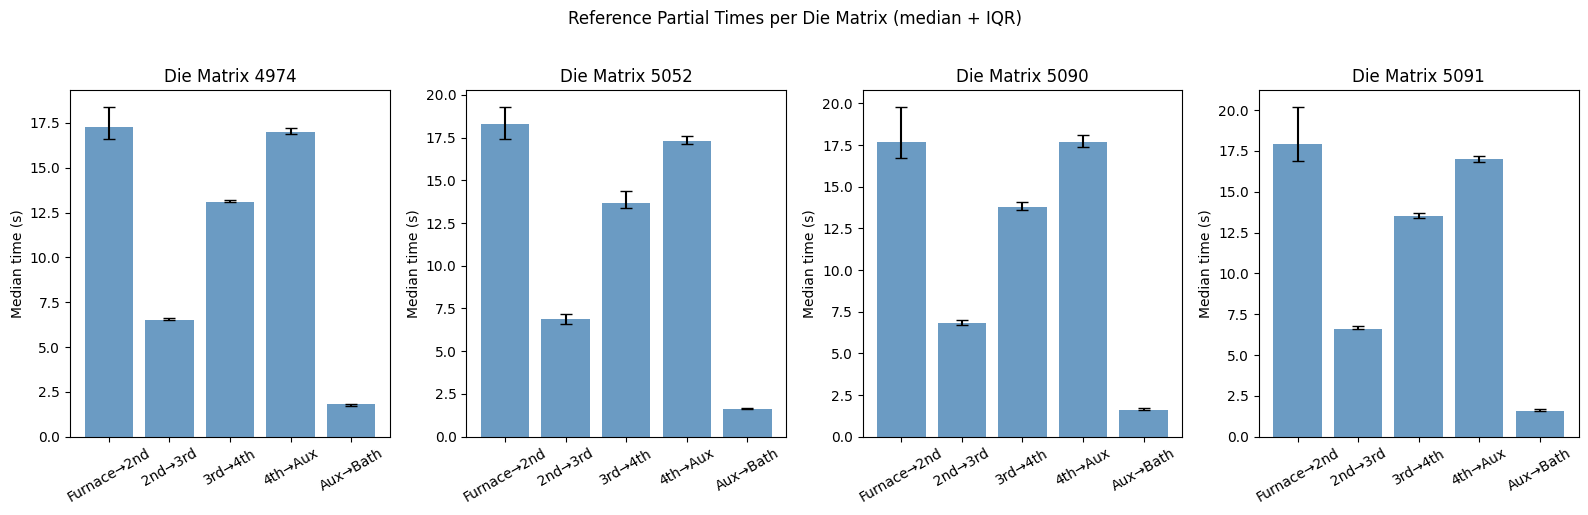

In [3]:
# Visualise reference profiles
matrices = sorted(df['die_matrix'].dropna().unique())
fig, axes = plt.subplots(1, len(matrices), figsize=(16, 5), sharey=False)

for ax, matrix in zip(axes, matrices):
    group = df[df['die_matrix'] == matrix][available_partial].dropna()
    medians = group.median()
    p25 = group.quantile(0.25)
    p75 = group.quantile(0.75)
    short_labels = PARTIAL_LABELS[:len(available_partial)]
    ax.bar(short_labels, medians.values, color='steelblue', alpha=0.8)
    ax.errorbar(short_labels, medians.values,
                yerr=[medians.values - p25.values, p75.values - medians.values],
                fmt='none', color='black', capsize=4)
    ax.set_title(f'Die Matrix {int(matrix)}')
    ax.set_ylabel('Median time (s)')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Reference Partial Times per Die Matrix (median + IQR)', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 2: Variability per segment

Coefficient of Variation (CV = std / median) per partial time per die matrix. High CV indicates an unstable segment — a candidate for process improvement.

=== Coefficient of Variation (std/median) per segment per die matrix ===
Higher CV = more variable = less stable segment


,Furnace→2nd,2nd→3rd,3rd→4th,4th→Aux,Aux→Bath
die_matrix,,,,,
4974,0.09,0.04,0.02,0.05,0.03
5052,0.10,0.07,0.06,0.07,0.03
5090,0.14,0.11,0.08,0.09,0.05
5091,0.14,0.11,0.09,0.06,0.07


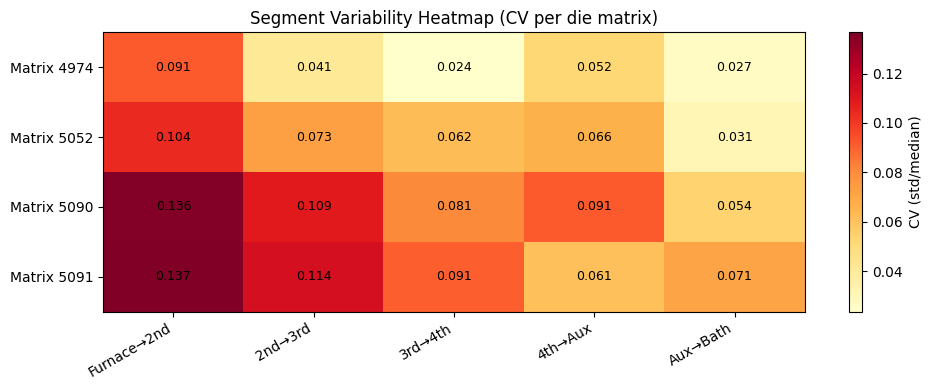

In [4]:
cv_data = []
for matrix in matrices:
    group = df[df['die_matrix'] == matrix][available_partial].dropna()
    medians = group.median()
    stds = group.std()
    cv = (stds / medians).round(4)
    row = {'die_matrix': int(matrix)}
    for col, label in zip(available_partial, PARTIAL_LABELS):
        row[label] = cv[col]
    cv_data.append(row)

df_cv = pd.DataFrame(cv_data).set_index('die_matrix')
print("=== Coefficient of Variation (std/median) per segment per die matrix ===")
print("Higher CV = more variable = less stable segment")
display(df_cv)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(df_cv.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(df_cv.columns)))
ax.set_xticklabels(df_cv.columns, rotation=30, ha='right')
ax.set_yticks(range(len(df_cv.index)))
ax.set_yticklabels([f'Matrix {m}' for m in df_cv.index])
plt.colorbar(im, ax=ax, label='CV (std/median)')
for i in range(len(df_cv.index)):
    for j in range(len(df_cv.columns)):
        ax.text(j, i, f'{df_cv.values[i, j]:.3f}', ha='center', va='center', fontsize=9)
ax.set_title('Segment Variability Heatmap (CV per die matrix)')
plt.tight_layout()
plt.show()

---
## Step 3: Deviations from reference

For each piece, compute how much each partial time deviates from its matrix median reference. Positive = slower than expected.

=== Mean deviation from reference (s) per die matrix ===
Positive = on average slower than reference


,dev_furnace_to_2nd_strike_s,dev_2nd_to_3rd_strike_s,dev_3rd_to_4th_strike_s,dev_4th_strike_to_auxiliary_press_s,dev_auxiliary_press_to_bath_s
die_matrix,,,,,
4974,0.46,0.07,0.10,0.06,-0.04
5052,0.31,0.05,0.25,0.04,0.04
5090,0.79,0.16,0.21,-0.08,0.02
5091,0.66,-0.00,0.26,0.04,0.04


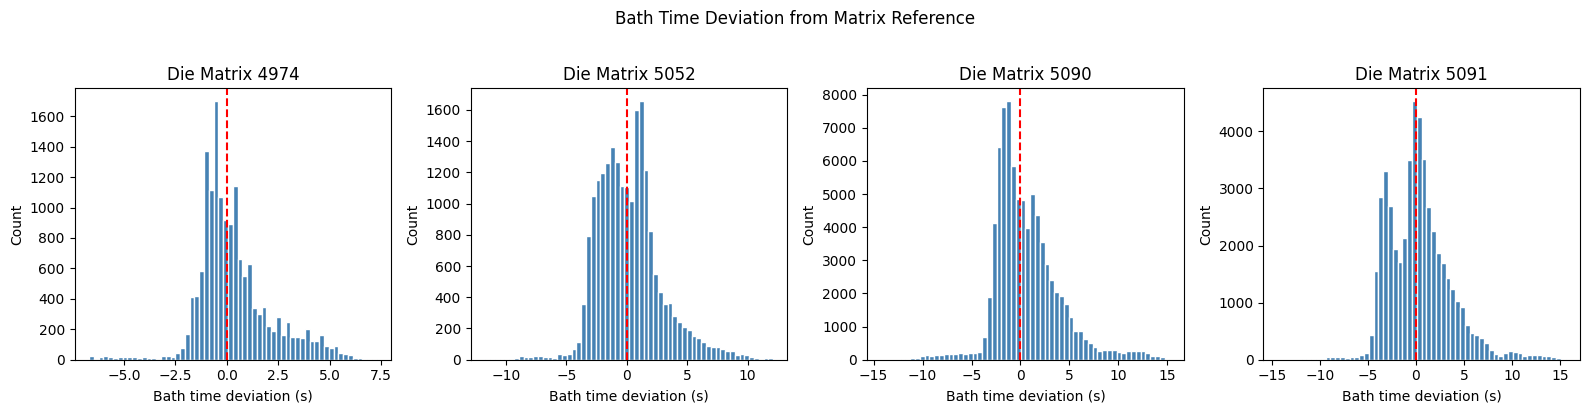

In [5]:
# Compute deviations
for col in available_partial:
    dev_col = col.replace('partial_', 'dev_')
    df[dev_col] = df.groupby('die_matrix')[col].transform(lambda x: x - x.median())

dev_cols = [c for c in df.columns if c.startswith('dev_')]

print("=== Mean deviation from reference (s) per die matrix ===")
print("Positive = on average slower than reference")
display(df.groupby('die_matrix')[dev_cols].mean().round(3))

# Distribution of bath time deviation
fig, axes = plt.subplots(1, len(matrices), figsize=(16, 4), sharey=False)
for ax, matrix in zip(axes, matrices):
    group = df[df['die_matrix'] == matrix]
    bath_dev = group['lifetime_bath_s'] - group['lifetime_bath_s'].median()
    ax.hist(bath_dev.dropna(), bins=60, color='steelblue', edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Reference')
    ax.set_title(f'Die Matrix {int(matrix)}')
    ax.set_xlabel('Bath time deviation (s)')
    ax.set_ylabel('Count')

plt.suptitle('Bath Time Deviation from Matrix Reference', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 4: Slow pieces and penalized segments

A piece is "slow" if its total bath time exceeds the 90th percentile for its die matrix. For each slow piece, the penalized segment is the partial time with the largest positive deviation from its matrix reference.

In [6]:
# Flag slow pieces
p90 = df.groupby('die_matrix')['lifetime_bath_s'].transform(lambda x: x.quantile(0.90))
df['is_slow'] = df['lifetime_bath_s'] > p90

print(f"Slow pieces (bath > P90 per matrix): {df['is_slow'].sum():,} / {len(df):,}")
print()
print(df.groupby('die_matrix').agg(
    total_pieces=('is_slow', 'count'),
    slow_pieces=('is_slow', 'sum')
).assign(pct_slow=lambda x: (100 * x['slow_pieces'] / x['total_pieces']).round(1)))

# Identify penalized segment for each slow piece
df_slow = df[df['is_slow']].copy()
if len(dev_cols) > 0:
    df_slow['penalized_segment'] = df_slow[dev_cols].idxmax(axis=1).str.replace('dev_', 'partial_')

    print("\n=== Most common penalized segment per die matrix ===")
    display(df_slow.groupby(['die_matrix', 'penalized_segment']).size()
            .rename('slow_pieces').reset_index()
            .sort_values(['die_matrix', 'slow_pieces'], ascending=[True, False]))

Slow pieces (bath > P90 per matrix): 16,549 / 169,154

            total_pieces  slow_pieces  pct_slow
die_matrix                                     
4974               15669         1535      9.80
5052               21153         2103      9.90
5090               82306         7970      9.70
5091               50026         4941      9.90

=== Most common penalized segment per die matrix ===


,die_matrix,penalized_segment,slow_pieces
3,4974,partial_furnace_to_2nd_strike_s,1328
2,4974,partial_4th_strike_to_auxiliary_press_s,185
1,4974,partial_3rd_to_4th_strike_s,18
0,4974,partial_2nd_to_3rd_strike_s,4
8,5052,partial_furnace_to_2nd_strike_s,1709
6,5052,partial_4th_strike_to_auxiliary_press_s,200
5,5052,partial_3rd_to_4th_strike_s,163
4,5052,partial_2nd_to_3rd_strike_s,30
7,5052,partial_auxiliary_press_to_bath_s,1
13,5090,partial_furnace_to_2nd_strike_s,5801


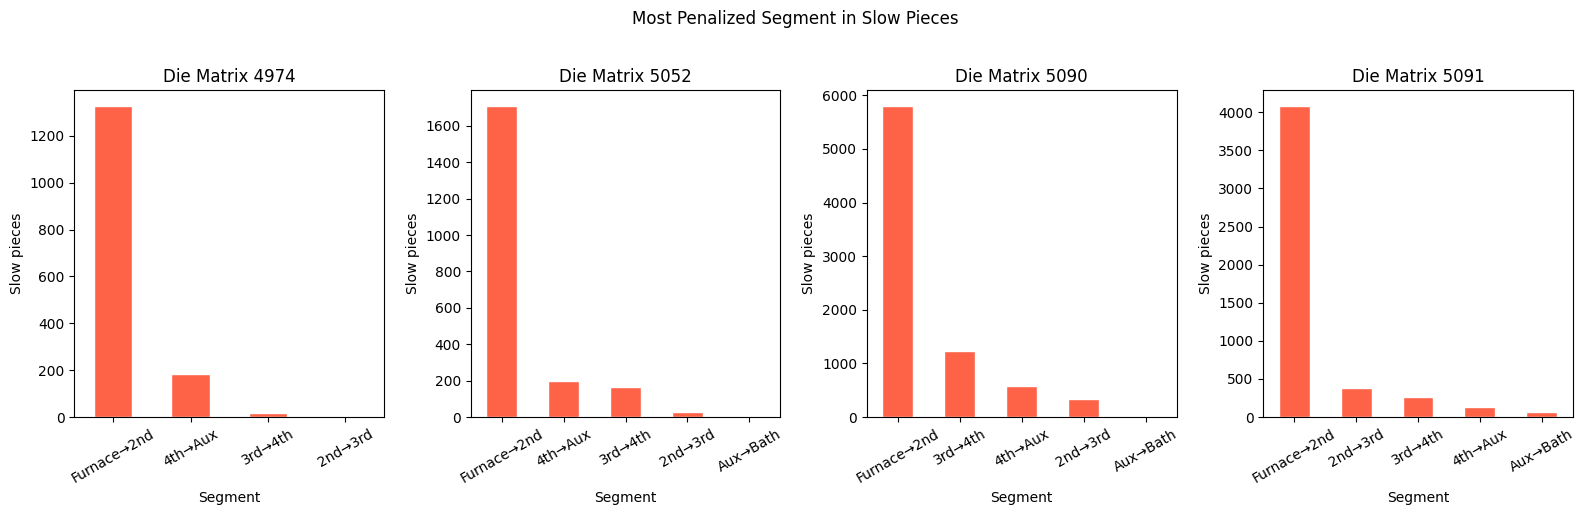

In [7]:
# Bar chart: penalized segment distribution per matrix
if 'penalized_segment' in df_slow.columns:
    fig, axes = plt.subplots(1, len(matrices), figsize=(16, 5))
    short_map = dict(zip(available_partial, PARTIAL_LABELS))

    for ax, matrix in zip(axes, matrices):
        group = df_slow[df_slow['die_matrix'] == matrix]
        counts = group['penalized_segment'].value_counts()
        counts.index = counts.index.map(short_map)
        counts.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
        ax.set_title(f'Die Matrix {int(matrix)}')
        ax.set_xlabel('Segment')
        ax.set_ylabel('Slow pieces')
        ax.tick_params(axis='x', rotation=30)

    plt.suptitle('Most Penalized Segment in Slow Pieces', y=1.02)
    plt.tight_layout()
    plt.show()

---
## Step 5: Drift over time

Compare daily median bath times at the start and end of each matrix's active period. Progressive increases may indicate tooling wear or process degradation.

In [8]:
# Daily median bath time per matrix
df_daily = (df.groupby(['die_matrix', 'date'])['lifetime_bath_s']
              .median().reset_index()
              .rename(columns={'lifetime_bath_s': 'median_bath_s'}))

# Drift summary: first vs last 5 days
print("=== Drift: first 5 days vs last 5 days median bath time (s) ===")
drift_rows = []
for matrix in matrices:
    days = df_daily[df_daily['die_matrix'] == matrix].sort_values('date')
    if len(days) < 10:
        continue
    early = days.head(5)['median_bath_s'].mean()
    late = days.tail(5)['median_bath_s'].mean()
    drift_rows.append({
        'die_matrix': int(matrix),
        'early_avg_s': round(early, 2),
        'late_avg_s': round(late, 2),
        'drift_s': round(late - early, 2),
        'drift_pct': round(100 * (late - early) / early, 2)
    })

display(pd.DataFrame(drift_rows).set_index('die_matrix'))

=== Drift: first 5 days vs last 5 days median bath time (s) ===


,early_avg_s,late_avg_s,drift_s,drift_pct
die_matrix,,,,
4974,56.72,56.46,-0.26,-0.46
5052,57.02,59.86,2.84,4.98
5090,56.70,61.84,5.14,9.07
5091,56.40,59.74,3.34,5.92


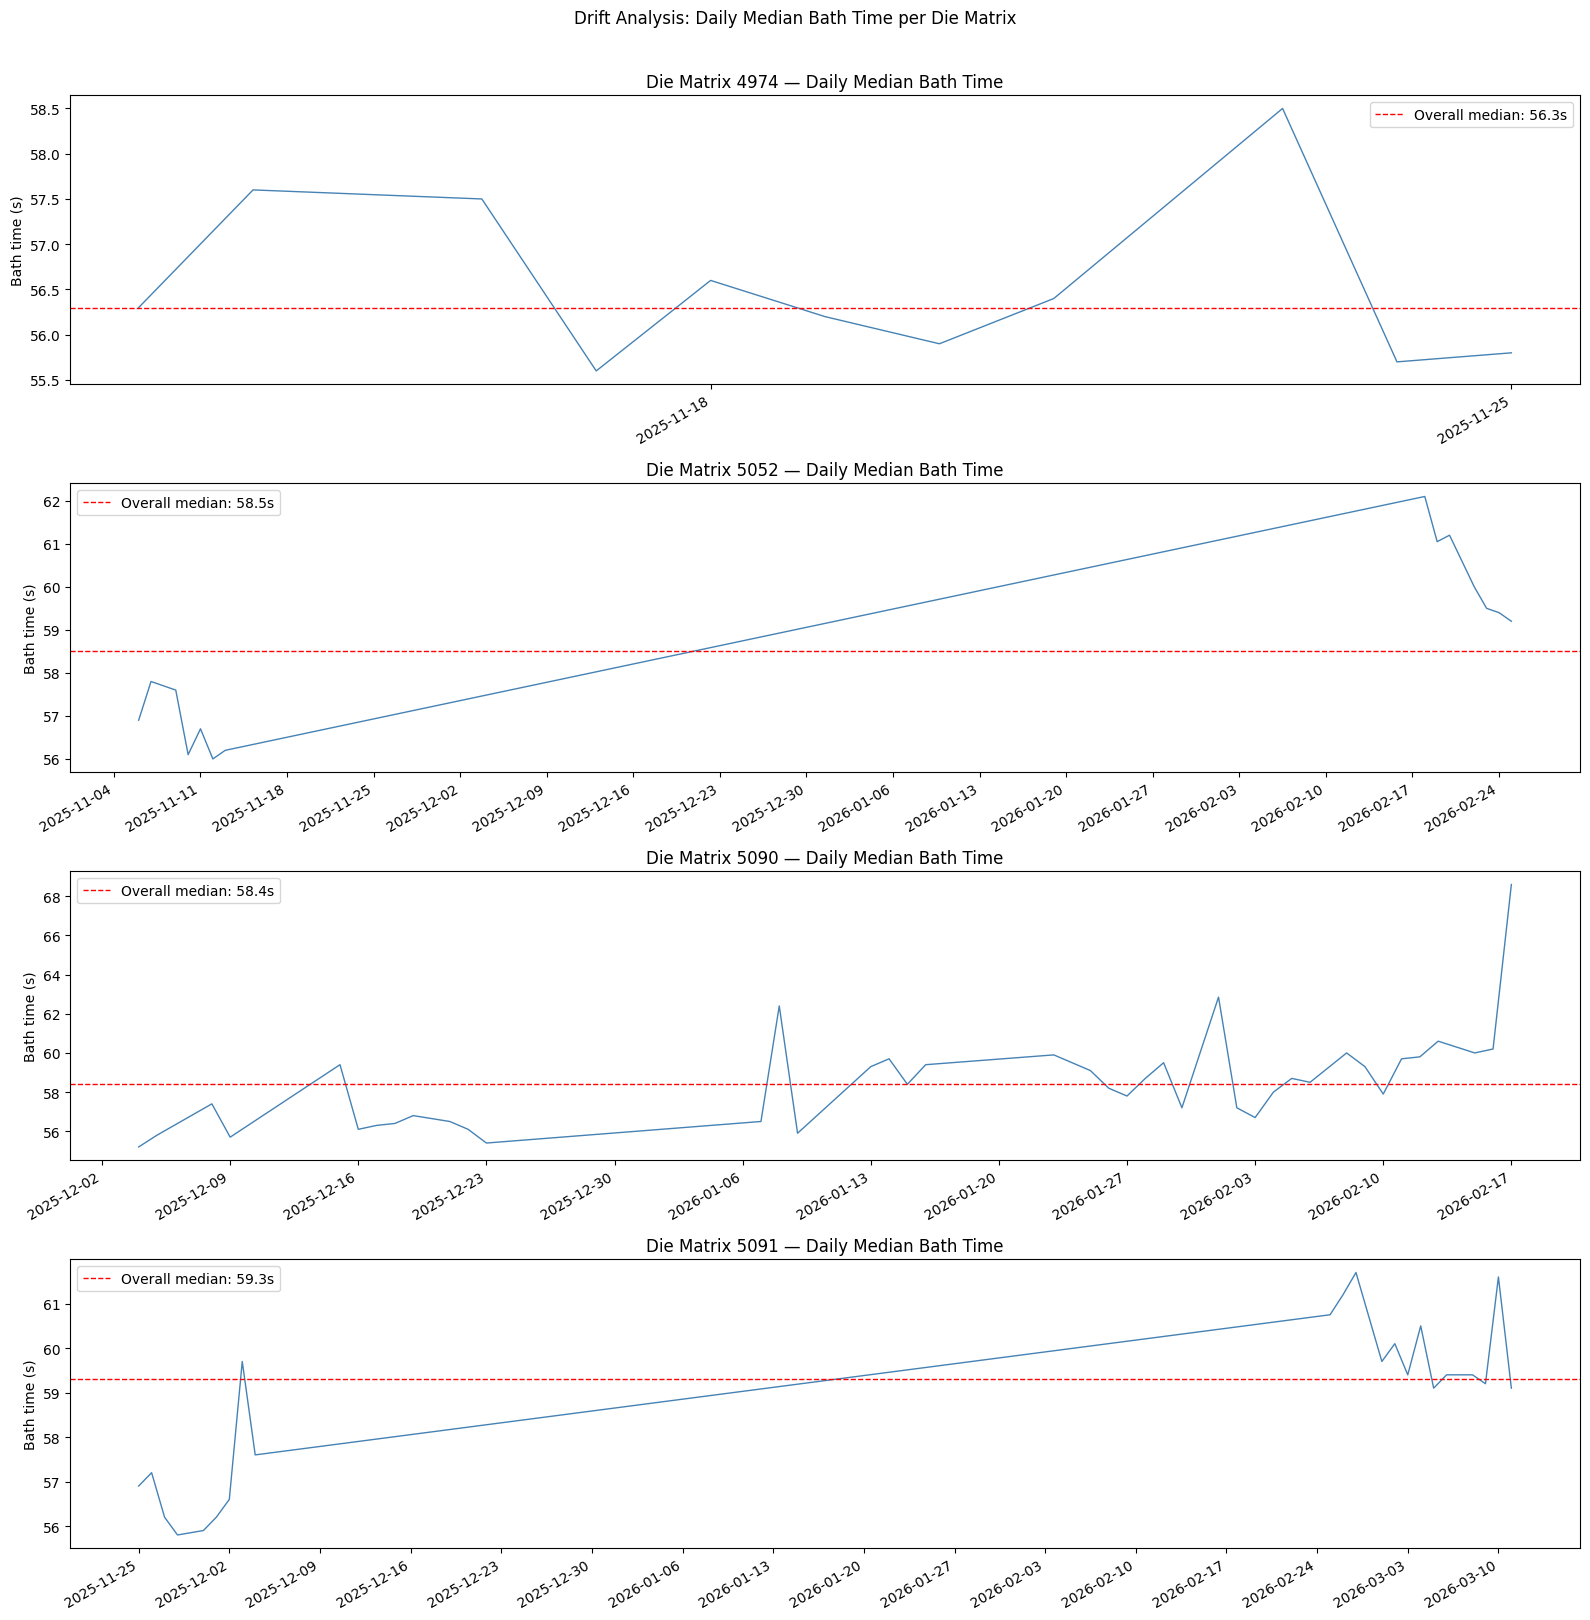

In [9]:
# Plot daily median bath time per matrix
fig, axes = plt.subplots(len(matrices), 1, figsize=(16, 4 * len(matrices)), sharex=False)

for ax, matrix in zip(axes, matrices):
    days = df_daily[df_daily['die_matrix'] == matrix].sort_values('date')
    ax.plot(pd.to_datetime(days['date']), days['median_bath_s'],
            color='steelblue', linewidth=1)
    overall_median = days['median_bath_s'].median()
    ax.axhline(overall_median, color='red', linestyle='--',
               linewidth=1, label=f'Overall median: {overall_median:.1f}s')
    ax.set_title(f'Die Matrix {int(matrix)} — Daily Median Bath Time')
    ax.set_ylabel('Bath time (s)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend()

plt.suptitle('Drift Analysis: Daily Median Bath Time per Die Matrix', y=1.01)
plt.tight_layout()
plt.show()